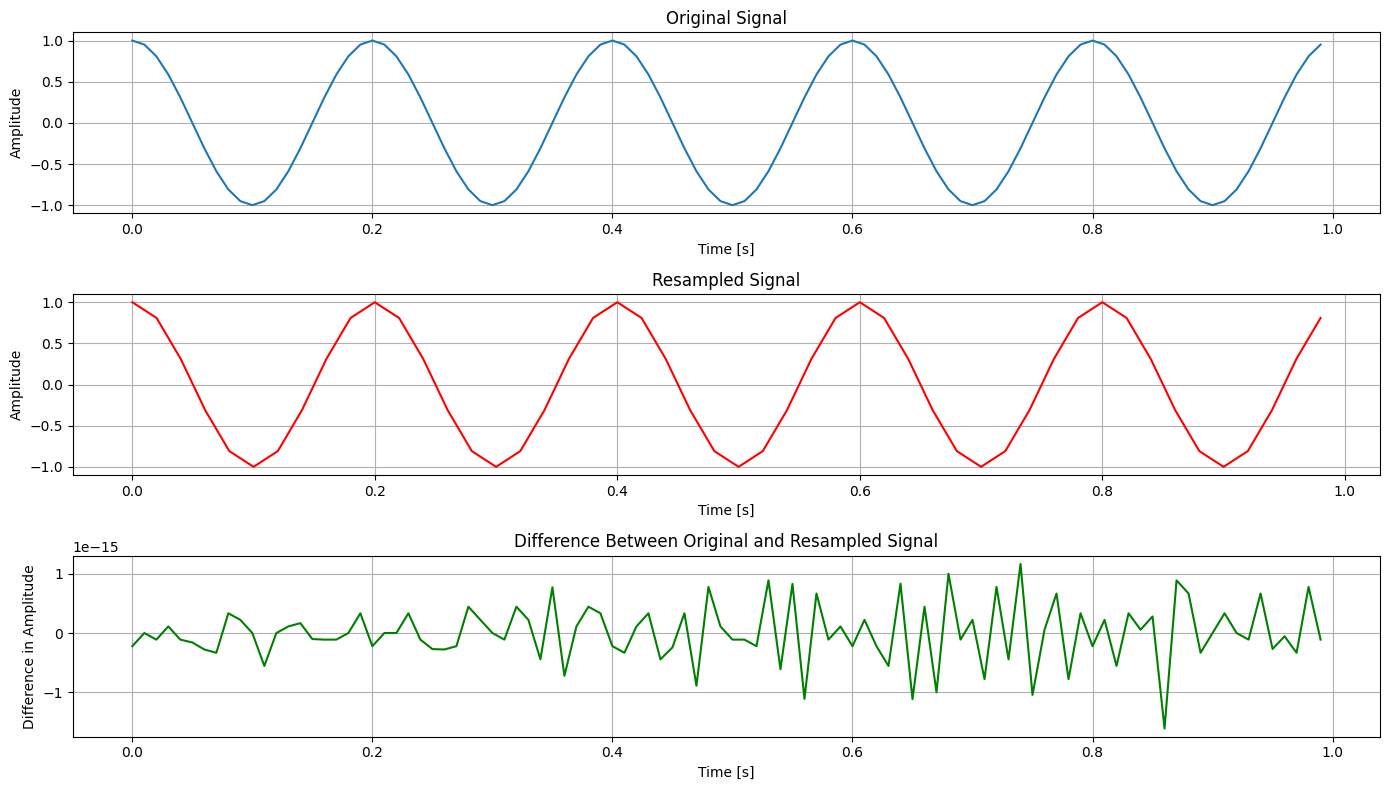

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample

# Создаем исходный сигнал
t = np.linspace(0, 1, 100, endpoint=False)
x = np.cos(2 * np.pi * 5 * t)  # Косинусоидальный сигнал с частотой 5 Гц

# Ресемплируем сигнал
num_samples_resampled = 50
x_resampled = resample(x, num_samples_resampled)
t_resampled = np.linspace(0, 1, num_samples_resampled, endpoint=False)

# Вычисляем разницу между исходным и ресемплированным сигналом
# Для корректного сравнения, сначала ресемплируем обратно к исходному количеству точек
x_resampled_back = resample(x_resampled, len(t))
difference = x - x_resampled_back

# Отрисовка исходного сигнала
plt.figure(figsize=(14, 8))
plt.subplot(3, 1, 1)
plt.plot(t, x, label='Original Signal')
plt.title('Original Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

# Отрисовка ресемплированного сигнала
plt.subplot(3, 1, 2)
plt.plot(t_resampled, x_resampled, label='Resampled Signal', color='r')
plt.title('Resampled Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

# Отрисовка разницы
plt.subplot(3, 1, 3)
plt.plot(t, difference, label='Difference', color='g')
plt.title('Difference Between Original and Resampled Signal')
plt.xlabel('Time [s]')
plt.ylabel('Difference in Amplitude')
plt.grid(True)

# Показать все графики
plt.tight_layout()
plt.show()


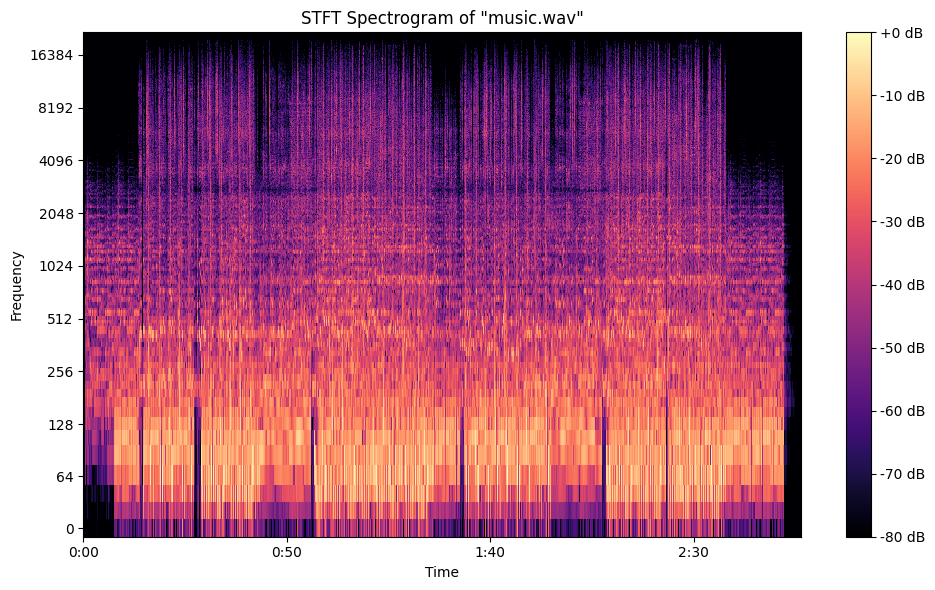

In [5]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Задаем путь к файлу
audio_file = '../data/audio/markul-nenormalnyj.mp3'

# Загрузка аудиофайла
y, sr = librosa.load(audio_file, sr=None, mono=True)  # sr=None гарантирует использование исходной частоты дискретизации

# Вычисление спектрограммы с использованием кратковременного преобразования Фурье (STFT)
D = librosa.stft(y)
# Перевод амплитудных значений в децибелы
D_dB = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# Визуализация спектрограммы
plt.figure(figsize=(10, 6))
librosa.display.specshow(D_dB, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('STFT Spectrogram of "music.wav"')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
